# PatchTST for Solar Power Forecasting

A from-scratch PyTorch implementation of PatchTST applied to the GEFCom2014 solar
task (cleaned Task-15 assembly). The dataset
`data/process/gefcom_task15_clean.parquet` contains three plants, 19,704 hourly
steps each, normalized POWER in [0, 1], and 12 NWP weather variables.

## Model overview

PatchTST splits each series into fixed-length patches, treats every patch as a
token, and applies a standard Transformer encoder to model the relationships
between patches. A linear head maps the encoded representation to the forecast
horizon. Two design choices distinguish it from earlier time-series Transformers:

1. **Patching** — consecutive time steps are grouped into a single token, which
   shortens the sequence (lower attention cost) and gives each token local
   semantic content rather than a single point.
2. **Channel independence** — each variable (channel) is processed independently
   with shared weights, reducing parameters and improving robustness.

## Contents

1. Data and forecasting task (sliding windows: 168h lookback -> 24h horizon)
2. `Dataset` / `DataLoader`
3. Model components: RevIN, patching, patch embedding, attention, encoder, head
4. Training loop (loss, AdamW, LR schedule, gradient clipping, early stopping)
5. Evaluation and diagnostics
6. Covariate variant (future NWP as known inputs)

## 1. Environment and reproducibility

A fixed random seed makes runs reproducible across weight initialization,
DataLoader shuffling, and dropout. The device defaults to Apple MPS when
available, then CUDA, then CPU.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, math, time, random
sys.path.insert(0, "/Users/lin_/Solar_Prediction")   # make `src` importable
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from src.helper.backtest import time_split
plt.rcParams["figure.figsize"] = (11, 4)

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything()

device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

# This env ships several OpenMP runtimes (torch, sklearn, skimage and cvxopt each
# bundle their own libomp/libgomp). If another one is loaded first, torch's
# threaded CPU kernels deadlock at 0% CPU or segfault on the first parallel op.
# Training runs on the GPU here, so one CPU thread costs nothing. Keeping torch
# imported before sklearn also avoids it, but this does not rely on that order.
if device != "cpu":
    torch.set_num_threads(1)

print("torch", torch.__version__, "| device:", device,
      "| cpu threads:", torch.get_num_threads())

torch 2.7.1 | device: mps


## 2. Configuration

All tunable settings in one place.

| Name | Value | Meaning |
|---|---|---|
| `SEQ_LEN` (L) | 168 | Lookback window (one week of hourly data). |
| `PRED_LEN` (H) | 24 | Forecast horizon (one day). |
| `PATCH_LEN` | 24 | Patch length; one patch spans a full day. |
| `STRIDE` | 24 | Patch step; equal to PATCH_LEN gives non-overlapping patches (168/24 = 7). |
| `D_MODEL` | 128 | Token embedding dimension. |
| `N_HEADS` | 8 | Number of attention heads (head dim 128/8 = 16). |
| `N_LAYERS` | 3 | Number of stacked encoder blocks. |
| `D_FF` | 256 | Feed-forward hidden dimension (typically 2-4x D_MODEL). |
| `DROPOUT` | 0.2 | Dropout rate. |

In [2]:
class Cfg:
    # task
    SEQ_LEN   = 168     # L: lookback window (one week)
    PRED_LEN  = 24      # H: forecast horizon (one day)
    # patching
    PATCH_LEN = 24      # patch length
    STRIDE    = 24      # patch stride (== PATCH_LEN -> non-overlapping)
    # transformer
    D_MODEL   = 128
    N_HEADS   = 8
    N_LAYERS  = 3
    D_FF      = 256
    DROPOUT   = 0.2
    # training
    BATCH     = 64
    LR        = 1e-3
    WEIGHT_DECAY = 1e-4
    EPOCHS    = 30
    PATIENCE  = 8       # early stopping: stop after PATIENCE epochs without val improvement
    GRAD_CLIP = 1.0

cfg = Cfg()
# number of patches per channel = (L - patch_len) / stride + 1
cfg.NUM_PATCHES = (cfg.SEQ_LEN - cfg.PATCH_LEN) // cfg.STRIDE + 1
print("num_patches per channel:", cfg.NUM_PATCHES)

num_patches per channel: 7


## 3. Data and forecasting task

### 3.1 Load and select channels

Channels: `POWER` (target) plus 12 NWP weather variables, 13 channels total.

Under channel independence the model forecasts each channel's own future 24 hours.
Only POWER (index 0) is evaluated; forecasting the weather channels adds a
self-supervised signal and follows the original PatchTST setup.

In [3]:
from src.helper.data_preprocessing import load_all_zones, NWP_VARS

CHANNELS = ["POWER"] + list(NWP_VARS)   # POWER at index 0, then 12 NWP variables
POWER_IDX = 0
n_channels = len(CHANNELS)

zone_dfs, df = load_all_zones(NWP_VARS)
df["POWER"] = df["POWER"].clip(0, 1)    # clip the single 1.004 overshoot

print("combined:", df.shape, "| channels:", n_channels)
print(CHANNELS)

combined: (59112, 15) | channels: 13
['POWER', 'VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166', 'VAR167', 'VAR169', 'VAR175', 'VAR178', 'VAR228']


### 3.2 Time-based train / val / test split
70% / 15% / 15% by timestamp

In [ ]:
# time_split 
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
FRACS = (TRAIN_FRAC, VAL_FRAC, 1 - TRAIN_FRAC - VAL_FRAC)   

# split each zone by time; windows never cross a zone/segment boundary
segments = {"train": [], "val": [], "test": []}
for z, g in df.groupby("ZONE"):
    tr, va, te = time_split(g.sort_values("ts"), FRACS)
    segments["train"].append((z, tr))
    segments["val"].append((z, va))
    segments["test"].append((z, te))

for name in ["train", "val", "test"]:
    rows = sum(len(g) for _, g in segments[name])
    print(f"{name:>5}: {rows:>6} rows across {len(segments[name])} zone-segments")

train:  41376 rows across 3 zone-segments
  val:   8868 rows across 3 zone-segments
 test:   8868 rows across 3 zone-segments


### 3.3 Normalization: global standardization + RevIN

The channels differ in scale by orders of magnitude (e.g. `VAR169` ~ 1e7, POWER in
[0, 1]). Two normalization stages are used together:

1. **Global per-channel standardization (z-score)** using train statistics, so all
   channels have comparable scale.
2. **RevIN (Reversible Instance Normalization)** inside the model, applied per input
   window and per channel, with the inverse transform on the output. This handles
   distribution shift, since each window uses its own statistics.

The loss is an MSE over all 13 channels; without global
standardization the large-scale weather channels dominate the gradient (squared
errors ~1e12) and POWER is effectively ignored. RevIN normalizes the input window
but does not equalize channel scales in the loss.

Standardization statistics are computed on the train segments only. POWER is
inverse-standardized back to [0, 1] for evaluation.

In [5]:
# per-channel mean/std computed on the train segments only (no leakage)
train_stack = np.concatenate(
    [g[CHANNELS].to_numpy(np.float32) for _, g in segments["train"]], axis=0)
ch_mean = train_stack.mean(axis=0)              # [C]
ch_std  = train_stack.std(axis=0) + 1e-8        # [C], eps guards against divide-by-zero
print("POWER  mean/std:", round(float(ch_mean[POWER_IDX]), 4), round(float(ch_std[POWER_IDX]), 4))
print("VAR169 mean/std:", f"{ch_mean[CHANNELS.index('VAR169')]:.3e}",
      f"{ch_std[CHANNELS.index('VAR169')]:.3e}")

POWER  mean/std: 0.1825 0.2728
VAR169 mean/std: 1.173e+07 6.195e+06


## 4. Dataset and DataLoader

Each sample is one sliding window:
- input `x`: shape `[C, L]` — the past L=168 hours across 13 channels
- target `y`: shape `[C, H]` — the following H=24 hours across 13 channels

For a segment of length N, valid start points t range from L to N-H, giving
N-L-H+1 windows.

Channels are placed first (`[C, L]` rather than `[L, C]`) because PatchTST slices
patches along time per channel and later reshapes to `[B*C, ...]`.

In [6]:
class WindowDataset(Dataset):
    """Sliding-window samples from (zone, segment) pairs; windows stay within a segment."""
    def __init__(self, zone_segments, channels, seq_len, pred_len, mean, std):
        self.L, self.H = seq_len, pred_len
        self.samples = []   # standardized array [N, C] per segment
        self.index = []     # (seg_id, start_t) for each window
        for seg_id, (z, g) in enumerate(zone_segments):
            arr = (g[channels].to_numpy(dtype=np.float32) - mean) / std  # global standardization
            self.samples.append(arr)
            N = len(arr)
            for t in range(seq_len, N - pred_len + 1):
                self.index.append((seg_id, t))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        seg_id, t = self.index[i]
        arr = self.samples[seg_id]
        x = arr[t - self.L : t]          # [L, C]
        y = arr[t : t + self.H]          # [H, C]
        x = torch.from_numpy(x).transpose(0, 1).contiguous()   # [C, L]
        y = torch.from_numpy(y).transpose(0, 1).contiguous()   # [C, H]
        return x, y

train_ds = WindowDataset(segments["train"], CHANNELS, cfg.SEQ_LEN, cfg.PRED_LEN, ch_mean, ch_std)
val_ds   = WindowDataset(segments["val"],   CHANNELS, cfg.SEQ_LEN, cfg.PRED_LEN, ch_mean, ch_std)
test_ds  = WindowDataset(segments["test"],  CHANNELS, cfg.SEQ_LEN, cfg.PRED_LEN, ch_mean, ch_std)
print(f"windows -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

train_dl = DataLoader(train_ds, batch_size=cfg.BATCH, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=cfg.BATCH, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=cfg.BATCH, shuffle=False)

xb, yb = next(iter(train_dl))
print("batch:  x", tuple(xb.shape), " y", tuple(yb.shape))   # [B, C, L] / [B, C, H]

windows -> train 40803 | val 8295 | test 8295
batch:  x (64, 13, 168)  y (64, 13, 24)


## 5. PatchTST components

The components are defined one at a time. The full data flow:

```
x                     [B, C, L]         input
 -> RevIN normalize   [B, C, L]         per-channel mean/std
 -> patching          [B, C, P, patch]  slice time into P patches
 -> merge channels    [B*C, P, patch]   channel independence: C folded into batch
 -> patch embedding   [B*C, P, d_model] linear projection + positional encoding
 -> Transformer x N    [B*C, P, d_model] self-attention over patches
 -> flatten head      [B*C, H]          flatten -> linear -> H-step forecast
 -> split channels    [B, C, H]
 -> RevIN denormalize [B, C, H]         back to input scale
```

### 5.1 RevIN — reversible instance normalization

For each sample and channel, compute the mean and standard deviation along time:
- normalize: `x' = (x - mean) / std`, then an optional learnable affine (gamma, beta)
- denormalize: invert on the output using the input window's mean and std

`eps` avoids division by zero when a channel is constant (e.g. POWER at night).
RevIN is the component that addresses distribution shift.

In [7]:
class RevIN(nn.Module):
    def __init__(self, n_channels, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if affine:
            self.gamma = nn.Parameter(torch.ones(n_channels))
            self.beta  = nn.Parameter(torch.zeros(n_channels))

    def forward(self, x, mode):
        # x: [B, C, T]
        if mode == "norm":
            self.mean = x.mean(dim=-1, keepdim=True).detach()          # [B, C, 1]
            self.std  = torch.sqrt(x.var(dim=-1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.std
            if self.affine:
                x = x * self.gamma[None, :, None] + self.beta[None, :, None]
            return x
        elif mode == "denorm":
            if self.affine:
                x = (x - self.beta[None, :, None]) / self.gamma[None, :, None]
            return x * self.std + self.mean
        raise ValueError(mode)

# round-trip check: norm then denorm should recover the input
_ri = RevIN(n_channels)
_x = torch.randn(4, n_channels, 168)
_back = _ri(_ri(_x, "norm"), "denorm")
print("RevIN round-trip max error:", (_x - _back).abs().max().item())

RevIN round-trip max error: 2.384185791015625e-07


### 5.2 Patching

`unfold` slides along time: `[B, C, L]` -> `[B, C, P, patch_len]`, where
`P = (L - patch_len) / stride + 1`. Here L=168, patch=24, stride=24 -> P=7 (one
patch per day). Patching reduces the token count from L=168 to P=7.

In [8]:
class Patchify(nn.Module):
    def __init__(self, patch_len, stride):
        super().__init__()
        self.patch_len, self.stride = patch_len, stride
    def forward(self, x):
        # [B, C, L] -> [B, C, P, patch_len]
        return x.unfold(dimension=-1, size=self.patch_len, step=self.stride)

_p = Patchify(cfg.PATCH_LEN, cfg.STRIDE)
print("patch output:", tuple(_p(torch.randn(4, n_channels, cfg.SEQ_LEN)).shape))

patch output: (4, 13, 7, 24)


### 5.3 Patch embedding and positional encoding

Two steps:
1. **Linear projection** of each patch (length 24) to `d_model=128`, producing one
   token vector per patch.
2. **Positional encoding**: self-attention is permutation-invariant, so patch order
   must be injected explicitly. PatchTST uses a learnable positional embedding
   (`[P, d_model]` parameters); fixed sinusoidal encodings are an alternative.

Channel independence is applied here: `[B, C, P, patch]` is reshaped to
`[B*C, P, patch]`, folding channels into the batch so all channels share the same
weights.

In [9]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_len, d_model, num_patches, dropout):
        super().__init__()
        self.proj = nn.Linear(patch_len, d_model)             # patch -> token
        self.pos  = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)  # learnable positions
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        # x: [B, C, P, patch_len]
        B, C, P, pl = x.shape
        x = x.reshape(B * C, P, pl)      # channel independence: fold C into batch
        x = self.proj(x)                 # [B*C, P, d_model]
        x = x + self.pos                 # add positional encoding (broadcast)
        return self.drop(x), B, C

_pe = PatchEmbedding(cfg.PATCH_LEN, cfg.D_MODEL, cfg.NUM_PATCHES, cfg.DROPOUT)
_out, _B, _C = _pe(_p(torch.randn(4, n_channels, cfg.SEQ_LEN)))
print("embedding output:", tuple(_out.shape), "| B, C =", _B, _C)

embedding output: (52, 7, 128) | B, C = 4 13


### 5.4 Multi-head self-attention

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.d_head = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        # x: [N, P, d_model]  (N = B*C)
        N, P, D = x.shape
        def split(t):  # [N, P, D] -> [N, h, P, d_head]
            return t.view(N, P, self.h, self.d_head).transpose(1, 2)
        q, k, v = split(self.q_proj(x)), split(self.k_proj(x)), split(self.v_proj(x))

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)  # [N, h, P, P]
        attn = scores.softmax(dim=-1)
        attn = self.drop(attn)
        out = attn @ v                                              # [N, h, P, d_head]
        out = out.transpose(1, 2).contiguous().view(N, P, D)       # concat heads
        out = self.o_proj(out)
        return (out, attn) if return_attn else out

_mha = MultiHeadAttention(cfg.D_MODEL, cfg.N_HEADS, 0.0)
_o, _a = _mha(_out, return_attn=True)
print("attn out:", tuple(_o.shape), "| attn weights:", tuple(_a.shape))  # [., ., P, P]

attn out: (52, 7, 128) | attn weights: (52, 8, 7, 7)


### 5.5 Encoder block

A standard Transformer encoder block has two sublayers, each wrapped as
`x + Sublayer(Norm(x))`:
1. **Multi-head self-attention** — patches exchange information
2. **Feed-forward network (FFN)** — `Linear -> GELU -> Linear`, a per-token
   non-linear transform that expands to `d_ff` and projects back

Residual connections provide a direct gradient path, and LayerNorm stabilizes each
sublayer's input. This uses **pre-norm** (normalize before the sublayer), which
trains more stably than the original post-norm.

In [11]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        # pre-norm residual blocks
        if return_attn:
            a_out, attn = self.attn(self.norm1(x), return_attn=True)
        else:
            a_out, attn = self.attn(self.norm1(x)), None
        x = x + self.drop(a_out)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return (x, attn) if return_attn else x

### 5.6 Forecast head

The encoder outputs a `[P, d_model]` representation per channel. The head flattens
it to a `P*d_model` vector and applies a linear layer to the H=24 horizon.

This is a direct multi-step head: all 24 steps are produced at once rather than
autoregressively, which is faster and avoids error accumulation.

In [12]:
class FlattenHead(nn.Module):
    def __init__(self, num_patches, d_model, pred_len, dropout):
        super().__init__()
        self.flatten = nn.Flatten(start_dim=-2)             # [., P, D] -> [., P*D]
        self.linear  = nn.Linear(num_patches * d_model, pred_len)
        self.drop    = nn.Dropout(dropout)
    def forward(self, x):
        return self.linear(self.drop(self.flatten(x)))      # [N, H]

### 5.7 Full model

The components are chained in the order of the data flow above. Each step in
`forward` is annotated with its tensor shape.

In [13]:
class PatchTST(nn.Module):
    def __init__(self, cfg, n_channels):
        super().__init__()
        self.revin  = RevIN(n_channels)
        self.patch  = Patchify(cfg.PATCH_LEN, cfg.STRIDE)
        self.embed  = PatchEmbedding(cfg.PATCH_LEN, cfg.D_MODEL, cfg.NUM_PATCHES, cfg.DROPOUT)
        self.blocks = nn.ModuleList([
            EncoderBlock(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.DROPOUT)
            for _ in range(cfg.N_LAYERS)
        ])
        self.head = FlattenHead(cfg.NUM_PATCHES, cfg.D_MODEL, cfg.PRED_LEN, cfg.DROPOUT)

    def forward(self, x, return_attn=False):
        # x: [B, C, L]
        x = self.revin(x, "norm")            # normalize
        x = self.patch(x)                    # [B, C, P, patch]
        z, B, C = self.embed(x)              # [B*C, P, d_model]
        attns = []
        for blk in self.blocks:
            z, a = blk(z, return_attn=return_attn) if return_attn else (blk(z), None)
            if return_attn: attns.append(a)
        y = self.head(z)                     # [B*C, H]
        y = y.reshape(B, C, -1)              # [B, C, H]
        y = self.revin(y, "denorm")          # denormalize to input scale
        return (y, attns) if return_attn else y

model = PatchTST(cfg, n_channels).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\ntrainable parameters: {n_params:,}")

PatchTST(
  (revin): RevIN()
  (patch): Patchify()
  (embed): PatchEmbedding(
    (proj): Linear(in_features=24, out_features=128, bias=True)
    (drop): Dropout(p=0.2, inplace=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x EncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (o_proj): Linear(in_features=128, out_features=128, bias=True)
        (drop): Dropout(p=0.2, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
   

### 5.8 Forward sanity check

Run one batch before training to confirm shapes line up and the forward pass runs.

In [14]:
model.eval()
with torch.no_grad():
    out = model(xb.to(device))
print("input x:", tuple(xb.shape), "-> output y_hat:", tuple(out.shape),
      "(expected [B, C, H] =", (cfg.BATCH, n_channels, cfg.PRED_LEN), ")")

input x: (64, 13, 168) -> output y_hat: (64, 13, 24) (expected [B, C, H] = (64, 13, 24) )


## 6. Training loop

- **Loss (MSE)**: computed over all 13 channels (multi-task self-supervision); only
  POWER is evaluated.
- **Optimizer (AdamW)**: Adam with decoupled weight decay, the standard choice for
  Transformers.
- **LR schedule (linear warmup + cosine decay)**: warmup ramps the learning rate
  from 0 to the peak over the first steps to avoid early divergence; cosine decay
  then anneals it toward 0 for fine-tuning.
- **Gradient clipping**: clips the gradient norm to `GRAD_CLIP=1.0`.
- **Early stopping**: evaluates on val each epoch, stops after `PATIENCE` epochs
  without improvement, and restores the best weights.

In [15]:
def make_scheduler(optimizer, warmup_steps, total_steps):
    """Linear warmup followed by cosine decay to 0; returns a LambdaLR."""
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
steps_per_epoch = len(train_dl)
total_steps  = steps_per_epoch * cfg.EPOCHS
warmup_steps = steps_per_epoch                    # warm up over the first epoch
scheduler = make_scheduler(optimizer, warmup_steps, total_steps)
print(f"steps/epoch={steps_per_epoch} | total={total_steps} | warmup={warmup_steps}")

steps/epoch=637 | total=19110 | warmup=637


In [16]:
@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    tot, n = 0.0, 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        loss = criterion(model(x), y)
        tot += loss.item() * x.size(0); n += x.size(0)
    return tot / n

def train_one_epoch(model, dl):
    model.train()
    tot, n = 0.0, 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)  # gradient clipping
        optimizer.step()
        scheduler.step()                                                   # step LR each batch
        tot += loss.item() * x.size(0); n += x.size(0)
    return tot / n

history = {"train": [], "val": [], "lr": []}
best_val, best_state, wait = float("inf"), None, 0

seed_everything()
for epoch in range(1, cfg.EPOCHS + 1):
    t0 = time.time()
    tr = train_one_epoch(model, train_dl)
    va = evaluate(model, val_dl)
    history["train"].append(tr); history["val"].append(va)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if va < best_val - 1e-6:
        best_val, wait = va, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        tag = "  <- best"
    else:
        wait += 1; tag = ""
    print(f"epoch {epoch:2d} | train {tr:.5f} | val {va:.5f} | "
          f"lr {history['lr'][-1]:.2e} | {time.time()-t0:4.1f}s{tag}")
    if wait >= cfg.PATIENCE:
        print(f"early stop at epoch {epoch} (no val improvement for {cfg.PATIENCE} epochs)")
        break

model.load_state_dict(best_state)   # restore best weights
print(f"\nbest val MSE: {best_val:.5f}")

epoch  1 | train 0.53813 | val 0.50774 | lr 1.00e-03 | 13.0s  <- best
epoch  2 | train 0.44175 | val 0.49351 | lr 9.97e-04 | 13.4s  <- best
epoch  3 | train 0.43128 | val 0.49020 | lr 9.88e-04 | 13.2s  <- best
epoch  4 | train 0.42324 | val 0.49470 | lr 9.74e-04 | 13.4s
epoch  5 | train 0.41621 | val 0.48530 | lr 9.54e-04 | 13.5s  <- best
epoch  6 | train 0.41066 | val 0.49534 | lr 9.28e-04 | 13.4s
epoch  7 | train 0.40619 | val 0.50498 | lr 8.98e-04 | 13.4s
epoch  8 | train 0.40081 | val 0.50780 | lr 8.63e-04 | 13.0s
epoch  9 | train 0.39701 | val 0.52544 | lr 8.24e-04 | 13.0s
epoch 10 | train 0.39353 | val 0.50989 | lr 7.81e-04 | 13.0s
epoch 11 | train 0.38722 | val 0.50777 | lr 7.34e-04 | 12.9s
epoch 12 | train 0.38298 | val 0.52666 | lr 6.85e-04 | 13.0s
epoch 13 | train 0.37855 | val 0.51825 | lr 6.34e-04 | 12.9s
early stop at epoch 13 (no val improvement for 8 epochs)

best val MSE: 0.48530


### 6.1 Learning curves

Train and val loss together indicate fit: both decreasing and close is healthy;
train down with val up is overfitting; both flat and high is underfitting or a
learning-rate problem. The learning-rate curve shows the warmup ramp and cosine
decay.

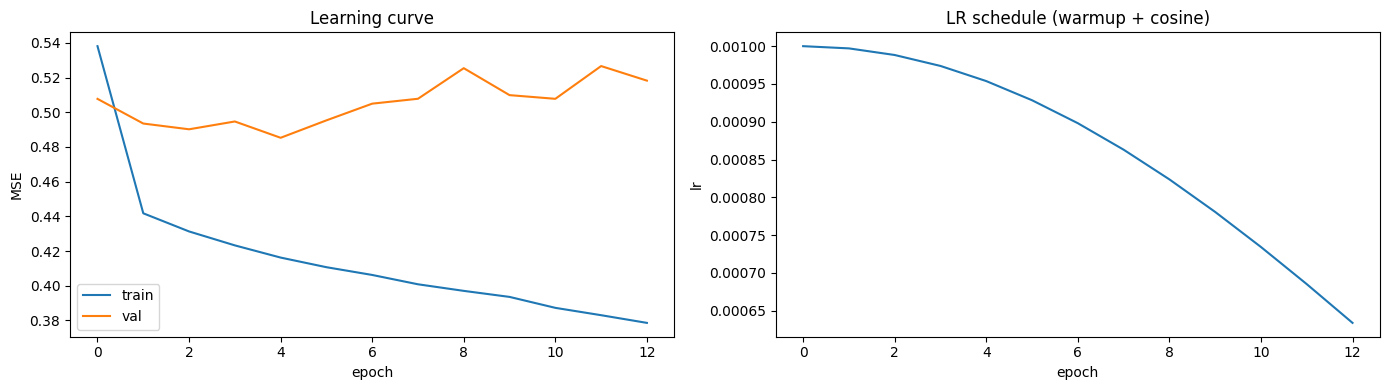

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history["train"], label="train")
ax[0].plot(history["val"],   label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE"); ax[0].legend()
ax[0].set_title("Learning curve")
ax[1].plot(history["lr"]);  ax[1].set_xlabel("epoch"); ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule (warmup + cosine)")
plt.tight_layout(); plt.show()

## 7. Test-set evaluation

Predictions are collected over the test set, POWER (index 0) is inverse-standardized
to [0, 1] and clipped, and RMSE / MAE are reported.

**Baseline (seasonal-naive)**: predict the value 24 hours earlier. Solar power has a
strong daily cycle, so this baseline is not trivial; beating it indicates the model
has learned useful structure.

In [18]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# predictions are in standardized space; invert to original POWER scale
P_MEAN, P_STD = float(ch_mean[POWER_IDX]), float(ch_std[POWER_IDX])
def inv_power(z):
    return z * P_STD + P_MEAN

@torch.no_grad()
def collect_predictions(model, dl):
    model.eval()
    P, Y = [], []
    for x, y in dl:
        pred = model(x.to(device)).cpu()
        P.append(pred[:, POWER_IDX, :])   # POWER channel -> [B, H]
        Y.append(y[:, POWER_IDX, :])
    return inv_power(torch.cat(P).numpy()), inv_power(torch.cat(Y).numpy())

pred, true = collect_predictions(model, test_dl)
pred = np.clip(pred, 0, 1)

# seasonal-naive: forecast the last H hours of the input (same hour, previous day)
@torch.no_grad()
def seasonal_naive(dl, pred_len):
    P, Y = [], []
    for x, y in dl:
        P.append(x[:, POWER_IDX, -pred_len:])
        Y.append(y[:, POWER_IDX, :])
    return inv_power(torch.cat(P).numpy()), inv_power(torch.cat(Y).numpy())

sn_pred, sn_true = seasonal_naive(test_dl, cfg.PRED_LEN)

def report(name, y, p):
    print(f"{name:<20} RMSE={root_mean_squared_error(y.ravel(), p.ravel()):.4f}  "
          f"MAE={mean_absolute_error(y.ravel(), p.ravel()):.4f}")

print("POWER channel, full 24h horizon:")
report("PatchTST", true, pred)
report("Seasonal-naive", sn_true, sn_pred)
sn_rmse = root_mean_squared_error(sn_true.ravel(), sn_pred.ravel())
imp = 1 - root_mean_squared_error(true.ravel(), pred.ravel()) / sn_rmse
print(f"\nPatchTST RMSE improvement over seasonal-naive: {imp*100:.1f}%")

POWER channel, full 24h horizon:
PatchTST             RMSE=0.1134  MAE=0.0587
Seasonal-naive       RMSE=0.1356  MAE=0.0600

PatchTST RMSE improvement over seasonal-naive: 16.4%


### 7.1 Error by horizon

Forecast error generally grows with lead time. The plot shows RMSE at each step from
1 to 24 hours ahead.

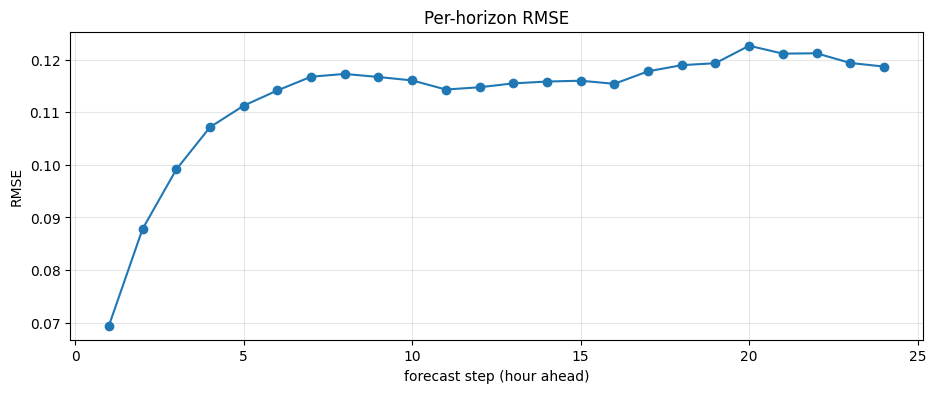

In [19]:
rmse_h = [root_mean_squared_error(true[:, h], pred[:, h]) for h in range(cfg.PRED_LEN)]
plt.plot(range(1, cfg.PRED_LEN + 1), rmse_h, marker="o")
plt.xlabel("forecast step (hour ahead)"); plt.ylabel("RMSE"); plt.title("Per-horizon RMSE")
plt.grid(alpha=0.3); plt.show()

### 7.2 Predicted vs actual

Left: 1-step (h=1) predictions across consecutive test windows. Right: predicted vs
actual scatter at h=1; closer to the diagonal is better.

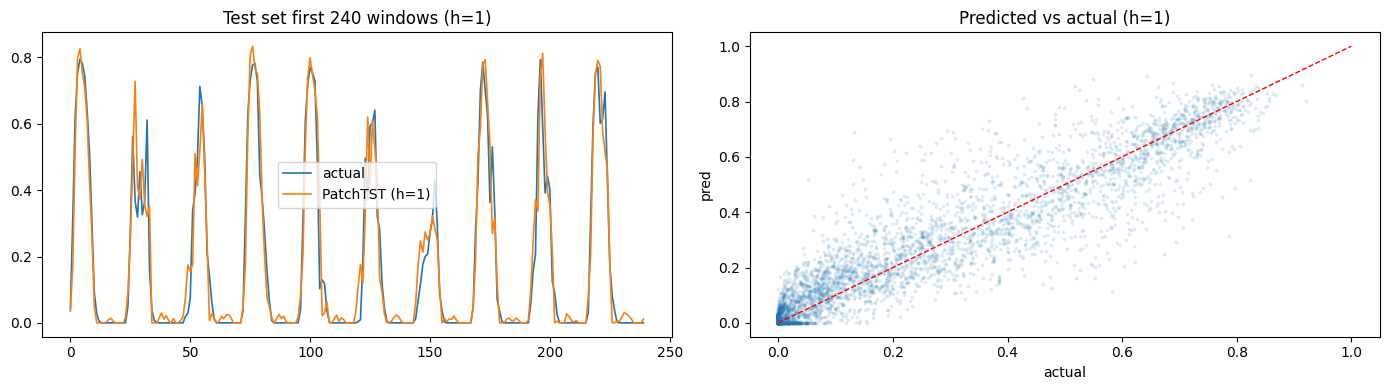

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
k = 240
ax[0].plot(true[:k, 0], label="actual", lw=1.2)
ax[0].plot(pred[:k, 0], label="PatchTST (h=1)", lw=1.2)
ax[0].set_title("Test set first 240 windows (h=1)"); ax[0].legend()
# scatter at h=1 only; using all horizons produces vertical banding from overlapping
# windows. Metrics above still use the full 24h horizon.
ax[1].scatter(true[:, 0], pred[:, 0], s=3, alpha=0.1)
ax[1].plot([0, 1], [0, 1], "r--", lw=1)
ax[1].set_xlabel("actual"); ax[1].set_ylabel("pred"); ax[1].set_title("Predicted vs actual (h=1)")
plt.tight_layout(); plt.show()

### 7.3 Attention weights

The `[P, P]` attention matrix for one sample, layer, and head. Rows are query
patches, columns are key patches, and color is the attention weight. Since each
patch spans a day, higher weights on nearby or periodically related days reflect the
structure the model has learned.

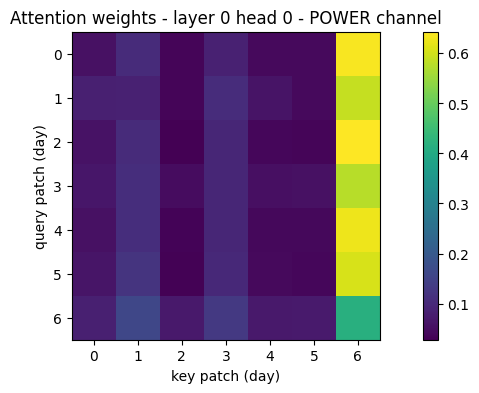

In [21]:
model.eval()
with torch.no_grad():
    _, attns = model(xb[:1].to(device), return_attn=True)   # one sample
# attns[layer]: [B*C, heads, P, P]; take POWER channel, layer 0, head 0
layer, head = 0, 0
A = attns[layer][POWER_IDX, head].cpu().numpy()
plt.imshow(A, cmap="viridis")
plt.colorbar(); plt.xlabel("key patch (day)"); plt.ylabel("query patch (day)")
plt.title(f"Attention weights - layer {layer} head {head} - POWER channel")
plt.show()

## 8. Variant: future NWP as known covariates

Sections 1-7 use a history-only setup: only past values are available, not future
weather. A contemporaneous-NWP regression baseline (e.g. gradient boosting) instead
maps same-hour weather forecasts to power, assuming future NWP is known (as provided
in GEFCom). The two setups are not directly comparable.

This variant supplies the next 24 hours of NWP as known future covariates, matching
that information setting.

Architecture:
```
past POWER            -> PatchTST encoder -> context ctx        --+
                                                                  +-- concat -> MLP head -> 24h POWER
future NWP (24h x 12) -> flatten + MLP    -> covariate features --+
```
- The encoder extracts autocorrelation and periodic structure from past POWER.
- The future NWP is the dominant signal for solar power (irradiance, cloud cover).
- The two branches are concatenated and an MLP head produces all 24 steps.

In [22]:
NWP_IDX = [CHANNELS.index(v) for v in NWP_VARS]   # positions of the 12 NWP channels
n_nwp = len(NWP_IDX)

class CovariateDataset(Dataset):
    """Returns (past POWER [1, L], future NWP [H, n_nwp], future POWER [H]) in standardized space."""
    def __init__(self, base_ds):
        self.base = base_ds                       # reuse WindowDataset's standardized arrays and index
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]                       # x: [C, L]  y: [C, H]
        past_power  = x[POWER_IDX:POWER_IDX+1, :]           # [1, L]
        future_nwp  = y[NWP_IDX, :].transpose(0, 1)         # [H, n_nwp]
        future_pow  = y[POWER_IDX, :]                       # [H]
        return past_power, future_nwp, future_pow

cov_train = DataLoader(CovariateDataset(train_ds), batch_size=cfg.BATCH, shuffle=True, drop_last=True)
cov_val   = DataLoader(CovariateDataset(val_ds),   batch_size=cfg.BATCH)
cov_test  = DataLoader(CovariateDataset(test_ds),  batch_size=cfg.BATCH)
pp, fn, fp = next(iter(cov_train))
print("past_power", tuple(pp.shape), "| future_nwp", tuple(fn.shape), "| target", tuple(fp.shape))

past_power (64, 1, 168) | future_nwp (64, 24, 12) | target (64, 24)


In [23]:
class CovariatePatchTST(nn.Module):
    def __init__(self, cfg, n_nwp):
        super().__init__()
        # branch 1: PatchTST encoder over past POWER (single channel)
        self.revin  = RevIN(1)
        self.patch  = Patchify(cfg.PATCH_LEN, cfg.STRIDE)
        self.embed  = PatchEmbedding(cfg.PATCH_LEN, cfg.D_MODEL, cfg.NUM_PATCHES, cfg.DROPOUT)
        self.blocks = nn.ModuleList([
            EncoderBlock(cfg.D_MODEL, cfg.N_HEADS, cfg.D_FF, cfg.DROPOUT) for _ in range(cfg.N_LAYERS)])
        ctx_dim = cfg.NUM_PATCHES * cfg.D_MODEL
        # branch 2: future NWP covariate encoder
        self.fut = nn.Sequential(
            nn.Linear(cfg.PRED_LEN * n_nwp, cfg.D_FF), nn.GELU(), nn.Dropout(cfg.DROPOUT))
        # fusion head
        self.head = nn.Sequential(
            nn.Linear(ctx_dim + cfg.D_FF, cfg.D_FF), nn.GELU(), nn.Dropout(cfg.DROPOUT),
            nn.Linear(cfg.D_FF, cfg.PRED_LEN))

    def forward(self, past_power, future_nwp):
        # past_power: [B, 1, L]  future_nwp: [B, H, n_nwp]
        x = self.revin(past_power, "norm")
        x = self.patch(x)
        z, B, C = self.embed(x)                    # [B*1, P, d]
        for blk in self.blocks: z = blk(z)
        ctx = z.reshape(B, -1)                     # [B, P*d]
        fut = self.fut(future_nwp.reshape(future_nwp.size(0), -1))   # [B, d_ff]
        out = self.head(torch.cat([ctx, fut], dim=-1))              # [B, H] standardized
        out = self.revin(out.unsqueeze(1), "denorm").squeeze(1)     # inverse RevIN
        return out

cov_model = CovariatePatchTST(cfg, n_nwp).to(device)
print("covariate model parameters:", f"{sum(p.numel() for p in cov_model.parameters()):,}")

covariate model parameters: 776,858


### 8.1 Training the covariate model

The training loop mirrors Section 6 (MSE, AdamW, warmup + cosine, gradient clipping,
early stopping); each batch is now a triple and the loss is on POWER only.

In [24]:
def train_covariate(model, train_dl, val_dl, epochs=cfg.EPOCHS):
    crit = nn.MSELoss()
    opt  = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sch  = make_scheduler(opt, len(train_dl), len(train_dl) * epochs)
    best, best_state, wait, hist = float("inf"), None, 0, {"train": [], "val": []}

    def run(dl, train):
        model.train() if train else model.eval()
        tot, n = 0.0, 0
        with torch.set_grad_enabled(train):
            for pp, fn, fp in dl:
                pp, fn, fp = pp.to(device), fn.to(device), fp.to(device)
                out = model(pp, fn)
                loss = crit(out, fp)
                if train:
                    opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
                    opt.step(); sch.step()
                tot += loss.item() * pp.size(0); n += pp.size(0)
        return tot / n

    seed_everything()
    for ep in range(1, epochs + 1):
        tr = run(train_dl, True); va = run(val_dl, False)
        hist["train"].append(tr); hist["val"].append(va)
        if va < best - 1e-6:
            best, wait = va, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            tag = "  <- best"
        else:
            wait += 1; tag = ""
        print(f"epoch {ep:2d} | train {tr:.5f} | val {va:.5f}{tag}")
        if wait >= cfg.PATIENCE:
            print(f"early stop at epoch {ep}"); break
    model.load_state_dict(best_state)
    return hist

cov_hist = train_covariate(cov_model, cov_train, cov_val)

epoch  1 | train 0.19049 | val 0.12124  <- best
epoch  2 | train 0.10623 | val 0.10170  <- best
epoch  3 | train 0.09635 | val 0.09344  <- best
epoch  4 | train 0.09245 | val 0.09036  <- best
epoch  5 | train 0.08930 | val 0.09089
epoch  6 | train 0.08706 | val 0.09077
epoch  7 | train 0.08517 | val 0.08960  <- best
epoch  8 | train 0.08268 | val 0.09457
epoch  9 | train 0.08119 | val 0.09248
epoch 10 | train 0.07945 | val 0.09229
epoch 11 | train 0.07807 | val 0.09423
epoch 12 | train 0.07611 | val 0.09278
epoch 13 | train 0.07473 | val 0.09086
epoch 14 | train 0.07336 | val 0.09339
epoch 15 | train 0.07169 | val 0.08888  <- best
epoch 16 | train 0.07003 | val 0.09055
epoch 17 | train 0.06879 | val 0.09199
epoch 18 | train 0.06781 | val 0.08865  <- best
epoch 19 | train 0.06677 | val 0.08946
epoch 20 | train 0.06536 | val 0.08763  <- best
epoch 21 | train 0.06397 | val 0.08840
epoch 22 | train 0.06317 | val 0.08703  <- best
epoch 23 | train 0.06219 | val 0.08808
epoch 24 | train 0.061

### 8.2 Comparison

The three approaches on the test set (POWER, inverse-standardized to [0, 1]):
- **Seasonal-naive**: same hour, previous day.
- **PatchTST (history-only)**: Section 7, no future weather.
- **PatchTST + future NWP**: this section, matching the covariate baseline's
  information.

Supplying future weather is expected to reduce error substantially, which shows that
the available information matters more than the model class for this task.

test set, POWER, full 24h horizon:
Seasonal-naive       RMSE=0.1356  MAE=0.0600
PatchTST (history)   RMSE=0.1134  MAE=0.0587
PatchTST + future NWP RMSE=0.0757  MAE=0.0383


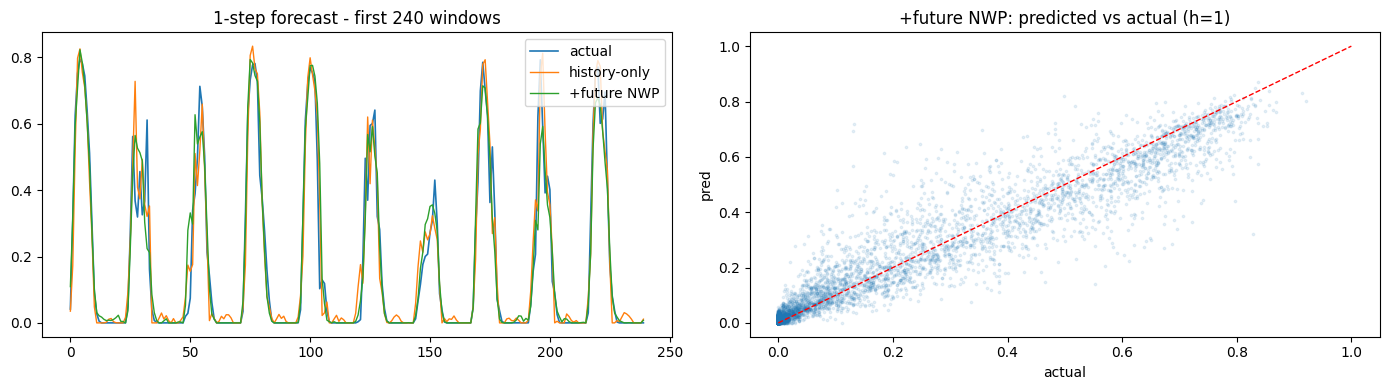

In [25]:
@torch.no_grad()
def collect_covariate(model, dl):
    model.eval(); P, Y = [], []
    for pp, fn, fp in dl:
        P.append(model(pp.to(device), fn.to(device)).cpu())
        Y.append(fp)
    return inv_power(torch.cat(P).numpy()), inv_power(torch.cat(Y).numpy())

cov_pred, cov_true = collect_covariate(cov_model, cov_test)
cov_pred = np.clip(cov_pred, 0, 1)

print("test set, POWER, full 24h horizon:")
report("Seasonal-naive",        sn_true, sn_pred)
report("PatchTST (history)",    true,    pred)
report("PatchTST + future NWP", cov_true, cov_pred)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
k = 240
ax[0].plot(cov_true[:k, 0], label="actual", lw=1.2)
ax[0].plot(pred[:k, 0],     label="history-only", lw=1)
ax[0].plot(cov_pred[:k, 0], label="+future NWP",  lw=1)
ax[0].set_title("1-step forecast - first 240 windows"); ax[0].legend()
# scatter at h=1 only
ax[1].scatter(cov_true[:, 0], cov_pred[:, 0], s=3, alpha=0.1)
ax[1].plot([0, 1], [0, 1], "r--", lw=1)
ax[1].set_xlabel("actual"); ax[1].set_ylabel("pred")
ax[1].set_title("+future NWP: predicted vs actual (h=1)")
plt.tight_layout(); plt.show()